In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np

In [ ]:
df = pd.read_parquet("../../data/model_ready/flights_model_ready.parquet")
df.head()


,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,near_holiday_3d
0,2018-01-03,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,3,Wednesday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Delayed,2018-01-03,10,27.0,10.0,6.000000,0.0,40.42,0.0,2,0.5,0.866025,0.974928,-0.222521,-1.181369,-1.795908,0.372,-0.268741,-1.032586,-0.532803,-506.21629,0,0,1
1,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,Thursday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.1,10.0,14.166667,0.0,54.36,21.0,3,0.5,0.866025,0.433884,-0.900969,-1.181369,-1.949265,0.372,1.558113,-0.405039,1.744748,-506.21629,0,0,1
2,2018-01-05,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,5,Friday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8877A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-05,10,17.1,10.0,12.153846,0.0,55.51,0.0,4,0.5,0.866025,-0.433884,-0.900969,-1.181369,-2.319438,0.372,1.107853,-0.353268,-0.532803,-506.21629,0,0,0
3,2018-01-06,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,6,Saturday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8970D,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-06,10,21.9,10.0,6.846154,0.0,57.02,0.0,5,0.5,0.866025,-0.974928,-0.222521,-1.181369,-2.065605,0.372,-0.079459,-0.285291,-0.532803,-506.21629,0,0,0
4,2018-01-07,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,7,Sunday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8980A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-07,10,21.9,10.0,7.384615,0.0,54.75,0.0,6,0.5,0.866025,-0.781831,0.623490,-1.181369,-2.065605,0.372,0.040993,-0.387482,-0.532803,-506.21629,0,0,0


In [3]:
df.isnull().sum().sort_values(ascending=False).head(20)

Tail_Number       51887
relh_std          15364
relh              15364
CRSElapsedTime        7
FlightDate            0
date                  0
sknt                  0
vsby                  0
tmpf                  0
dep_hour              0
year                  0
target                0
DistanceGroup         0
ArrTimeBlk            0
CRSArrTime            0
DepTimeBlk            0
DestWac               0
p01i                  0
gust                  0
DestStateFips         0
dtype: int64

### Sampling Strategy

Another thing to consider for RF, is to sample data to not train on entire dataset.

Due to the scale of the dataset (~29M flights), we applied a multi-stage sampling strategy. 

Data were first sampled evenly across months to retain seasonal patterns. Next, the contribution of any single origin airport was capped at 5% to prevent dominance by major hubs. Finally, the sample was stratified by the target variable (on-time, delayed, cancelled) on a best-effort basis to improve class balance. This approach maintains temporal, geographic, and outcome diversity while producing a manageable dataset for baseline modeling.



In [4]:
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
TOTAL_SAMPLE = 600_000          # target total rows
MAX_ORIGIN_FRAC = 0.05          # no single origin >5%
RANDOM_STATE = 42

# -----------------------------
# PREP
# -----------------------------
df = df.copy()
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
df["month"] = df["FlightDate"].dt.to_period("M").astype(str)

# -----------------------------
# STEP 1: BALANCE MONTHS
# -----------------------------
n_months = df["month"].nunique()
rows_per_month = TOTAL_SAMPLE // n_months

month_samples = []
for m, g in df.groupby("month"):
    month_samples.append(
        g.sample(
            n=min(len(g), rows_per_month),
            random_state=RANDOM_STATE
        )
    )

month_balanced = pd.concat(month_samples, ignore_index=True)

# -----------------------------
# STEP 2: CAP ORIGIN DOMINANCE
# -----------------------------
origin_cap = int(len(month_balanced) * MAX_ORIGIN_FRAC)

origin_balanced = (
    month_balanced
    .groupby("Origin", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), origin_cap),
            random_state=RANDOM_STATE
        )
    )
)

# -----------------------------
# STEP 3: STRATIFY TARGET
# -----------------------------
n_classes = origin_balanced["target"].nunique()
rows_per_class = len(origin_balanced) // n_classes

final_sample = (
    origin_balanced
    .groupby("target", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), rows_per_class),
            random_state=RANDOM_STATE
        )
    )
)

# -----------------------------
# FINAL CHECKS TO ENSURE TRAINING DATA REPRESENTS ENTIRE DATASET WE HAVE
# -----------------------------
print("Final rows:", len(final_sample))
print("\nTarget distribution:")
print(final_sample["target"].value_counts(normalize=True))

print("\nTop origins:")
print(final_sample["Origin"].value_counts(normalize=True).head())

print("\nMonth distribution:")
print(final_sample["month"].value_counts(normalize=True).sort_index())


Final rows: 303476

Target distribution:
target
On time      0.611386
Delayed      0.353303
Cancelled    0.035311
Name: proportion, dtype: float64

Top origins:
Origin
DEN    0.056110
DFW    0.054963
ORD    0.054456
ATL    0.051622
LAX    0.051233
Name: proportion, dtype: float64

Month distribution:
month
2018-01    0.023712
2018-02    0.023587
2018-03    0.023929
2018-04    0.022809
2018-05    0.024308
2018-06    0.024338
2018-07    0.024424
2018-08    0.024806
2018-09    0.022176
2018-10    0.021965
2018-11    0.023020
2018-12    0.022941
2019-01    0.022974
2019-02    0.023969
2019-03    0.022957
2019-04    0.022938
2019-05    0.023758
2019-06    0.024358
2019-07    0.023804
2019-08    0.023867
2019-09    0.021863
2019-10    0.022074
2019-11    0.021297
2019-12    0.023501
2021-01    0.020028
2021-02    0.022213
2021-03    0.020710
2021-04    0.020822
2021-05    0.021570
2021-06    0.024200
2021-07    0.024226
2021-08    0.024443
2021-09    0.021903
2021-10    0.022905
2021-11    0

In [5]:
# -----------------------------
# TRAIN / VAL / TEST SPLIT
# -----------------------------
final_sample = final_sample.sort_values("FlightDate")

n = len(final_sample)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = final_sample.iloc[:train_end]
val_df   = final_sample.iloc[train_end:val_end]
test_df  = final_sample.iloc[val_end:]

# -----------------------------
# CHECKS
# -----------------------------
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain target distribution:")
print(train_df["target"].value_counts(normalize=True))

print("\nTest target distribution:")
print(test_df["target"].value_counts(normalize=True))

print("\nDate ranges:")
print("Train:", train_df["FlightDate"].min(), "→", train_df["FlightDate"].max())
print("Test :", test_df["FlightDate"].min(), "→", test_df["FlightDate"].max())


Train: (212433, 68)
Val: (45521, 68)
Test: (45522, 68)

Train target distribution:
target
On time      0.627770
Delayed      0.341209
Cancelled    0.031022
Name: proportion, dtype: float64

Test target distribution:
target
On time      0.549690
Delayed      0.400993
Cancelled    0.049317
Name: proportion, dtype: float64

Date ranges:
Train: 2018-01-01 00:00:00 → 2021-07-14 00:00:00
Test : 2022-01-27 00:00:00 → 2022-07-30 00:00:00


In [6]:
val_df = (
    val_df
    .groupby("target", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), 50_000),
        random_state=42
    ))
)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## Random Forest Model Baseline

Features based off of EDA:
- Airline
- DeptTimeBlk
- DistanceGroup
- Month
- Dep_Hour
- Weather
- DayofWeek

In [8]:
FEATURES = ["Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour", "DepTimeBlk",
    "Airline", "Origin", "Dest", "Distance", "DistanceGroup",
    "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

TARGET = "target"


In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numerical
categorical_features = [
    "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
]

numeric_features = [
    "Quarter", "Month", "DayofMonth", "dep_hour",
    "Distance", "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)



In [10]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


In [11]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])


In [12]:
# Make copies to be safe
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

# Convert categorical columns to string (needed for OneHotEncoder)
for col in categorical_features:
    train_df[col] = train_df[col].astype(str)
    val_df[col]   = val_df[col].astype(str)
    test_df[col]  = test_df[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    train_df[col] = train_df[col].fillna(0)
    val_df[col]   = val_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
for col in categorical_features:
    train_df[col] = train_df[col].fillna("missing")
    val_df[col]   = val_df[col].fillna("missing")
    test_df[col]  = test_df[col].fillna("missing")


In [13]:
pipeline.fit(train_df[FEATURES], train_df[TARGET])


/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['DepTimeBlk', 'Airline',
                                                   'Origin', 'Dest',
                                                   'DistanceGroup',
                                                   'DayOfWeek']),
                                                 ('num', 'passthrough',
                                                  ['Quarter', 'Month',
                                                   'DayofMonth', 'dep_hour',
                                                   'Distance', 'tmpf', 'vsby',
                                                   'sknt', 'p01i', 'relh',
                                                   'gust'])])),
                ('rf',
                 RandomForestClassifier(max_depth=15, n_estimators=80,
                                        n_jobs=-1, random_state=42))])

In [14]:
# Predictions
y_pred = pipeline.predict(test_df[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(test_df[TARGET], y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(test_df[TARGET], y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)



Classification Report:



/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

   Cancelled      0.000     0.000     0.000      2245
     Delayed      0.677     0.082     0.146     18254
     On time      0.566     0.980     0.717     25023

    accuracy                          0.571     45522
   macro avg      0.414     0.354     0.288     45522
weighted avg      0.583     0.571     0.453     45522


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled        0.0  0.090423  0.909577
Delayed          0.0  0.081626  0.918374
On time          0.0  0.020261  0.979739


/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Test Accuracy: 0.571

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled          0      203     2042
Delayed            0     1490    16764
On time            0      507    24516

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled        0.0  0.090423  0.909577
Delayed          0.0  0.081626  0.918374
On time          0.0  0.020261  0.979739


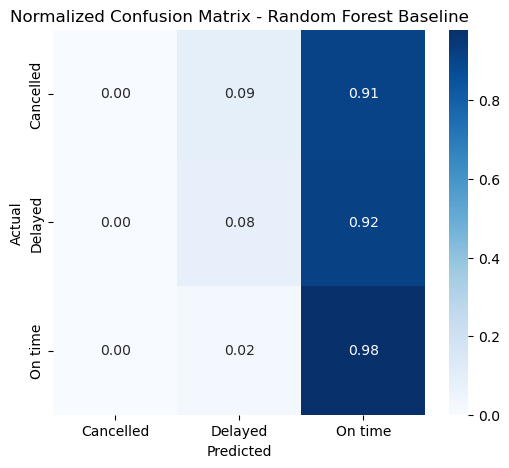


Classification Report:


/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

   Cancelled      0.000     0.000     0.000      2245
     Delayed      0.677     0.082     0.146     18254
     On time      0.566     0.980     0.717     25023

    accuracy                          0.571     45522
   macro avg      0.414     0.354     0.288     45522
weighted avg      0.583     0.571     0.453     45522



/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(test_df[FEATURES])
y_true = test_df[TARGET]

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))


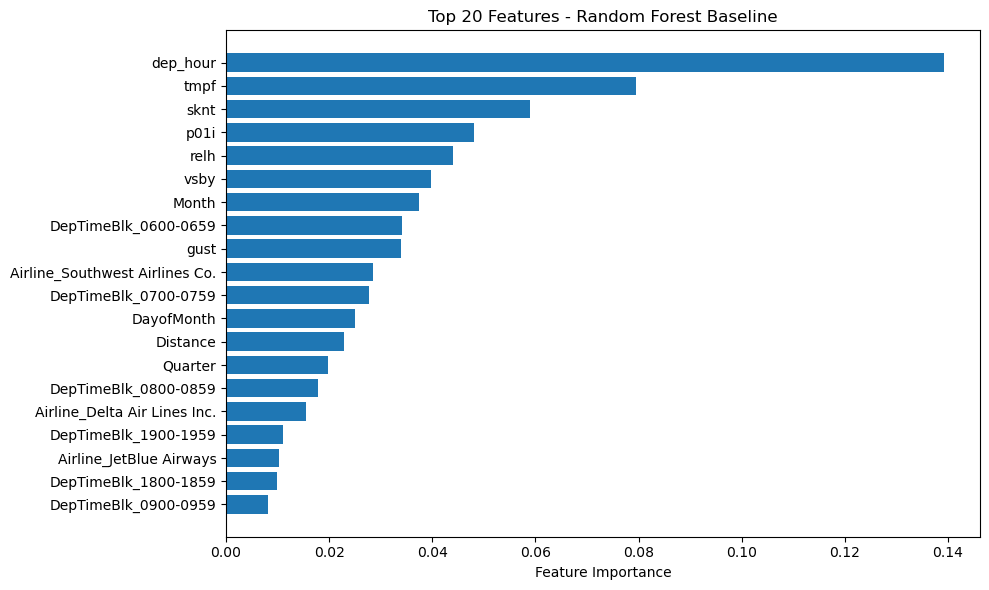

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = np.concatenate([cat_features, numeric_features])

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()
